In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Controller per 'n' defender

In [9]:
# Load best controller found for each 'n' by CMA-ES
best_each_n = pd.read_json("kcm_results/best_of_each_n.json", orient="columns")

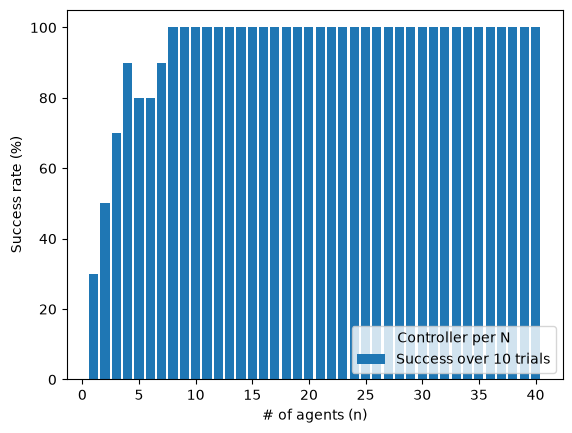

In [10]:
# Plot best data
x, y = best_each_n["n"], best_each_n["best_fitness"] * -100
plt.bar(x, y, label="Success over 10 trials")
plt.xlabel("# of agents (n)")
plt.ylabel("Success rate (%)")
plt.legend(title="Controller per N", loc="lower right")

# Analysis of controller over 'n'

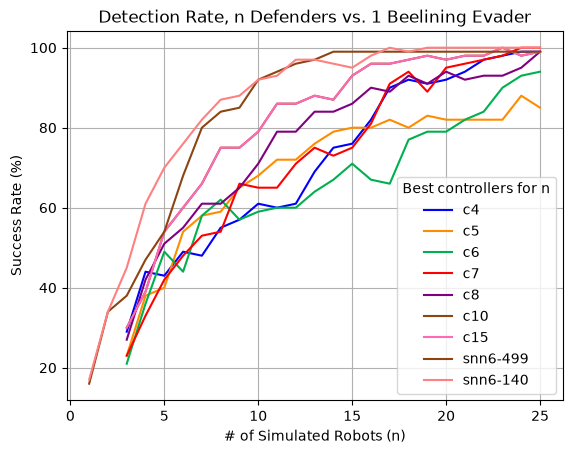

In [11]:
best_each_n = pd.read_json("kcm_results/eval_over_n.json")
n_range = [*range(3, 25+1)]

line_colors = [
    (0.0, 0.0, 1.0),   # Blue
    (1.0, 0.55, 0.0),  # Orange
    (0.0, 0.69, 0.31), # Green
    (1.0, 0.0, 0.0),   # Red
    (0.5, 0.0, 0.5),   # Purple
    (0.55, 0.27, 0.07),# Brown
    (1.0, 0.41, 0.71)  # Pink
]

plt.xlabel("# of Simulated Robots (n)")
plt.ylabel("Success Rate (%)")
plt.grid()
for i, column in enumerate(best_each_n.columns):
    plt.plot(
        n_range, best_each_n[column] * 100,
        color=line_colors[i % len(line_colors)], label=column
    )

snn_df = pd.read_csv('farp1-v01-None499.csv', index_col=0)
snn_col = snn_df.groupby('n')['fitness'].mean()

plt.plot(
    snn_col.index, snn_col.values * 100,
    color=line_colors[-2], label='snn6-499'
)

snn_df = pd.read_csv('farp1-v01-None.csv', index_col=0)
snn_col = snn_df.groupby('n')['fitness'].mean()

plt.plot(
    snn_col.index, snn_col.values * 100,
    color=(1.0, 0.5, 0.5), label='snn6-140'
)

plt.legend(loc="best", title="Best controllers for n")
plt.title("Detection Rate, n Defenders vs. 1 Beelining Evader")
plt.show()

In [12]:
snn_col.values

array([0.17, 0.34, 0.45, 0.61, 0.7 , 0.76, 0.82, 0.87, 0.88, 0.92, 0.93,
       0.97, 0.97, 0.96, 0.95, 0.98, 1.  , 0.99, 1.  , 1.  , 1.  , 1.  ,
       1.  , 1.  , 1.  ])

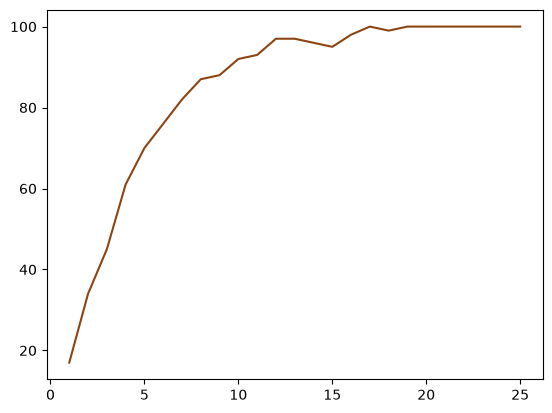

In [13]:
plt.plot(
    snn_col.index, snn_col.values * 100,
    color=line_colors[-2], label='snn6'
)